### Build a basic Chatbot with Langgraph (Graph API)

In [1]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START,END
from langgraph.graph.message import add_messages  ## is a reducer

In [2]:
class State(TypedDict):
    # messages have the type list. The add_messages function
    # in the annotation defines how this state key should be updated
    #(in this case), it appends messages to the list, rather than overwriting them
    messages:Annotated[list, add_messages]

graph_builder = StateGraph(State)



In [3]:
graph_builder

In [4]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [5]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm = ChatGroq(model = "openai/gpt-oss-20b")

In [6]:
# Node functionality
def chatbot(state:State):
    return {"messages" : [llm.invoke(state["messages"])]}

In [7]:
graph_builder = StateGraph(State)

# adding node
graph_builder.add_node("llmchatbot", chatbot)

#adding edges
graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_edge("llmchatbot", END )

## compiling the graph
graph = graph_builder.compile()

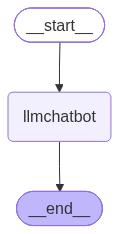

In [8]:
## visualize the graph

from IPython.display import Image, display
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass


In [9]:
response = graph.invoke({"messages" : "Hi"})
response

{'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='7287fbc9-8e66-4c3b-a956-64c169ffc280'),
  AIMessage(content='Hello! 👋 How can I help you today?', additional_kwargs={'reasoning_content': 'User says "Hi". We need to respond politely. It\'s a greeting. Just respond "Hello! How can I help you today?"'}, response_metadata={'token_usage': {'completion_tokens': 48, 'prompt_tokens': 72, 'total_tokens': 120, 'completion_time': 0.048851422, 'completion_tokens_details': {'reasoning_tokens': 28}, 'prompt_time': 0.003803698, 'prompt_tokens_details': None, 'queue_time': 0.303602707, 'total_time': 0.05265512}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_639a5351c8', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a06693-e969-72f3-81ff-2e83ecae1505-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 72, 'output_tokens': 48, 'total_tokens': 120, 'output_token

In [10]:
response = graph.invoke({"messages" : "What is your name ?"})
response

{'messages': [HumanMessage(content='What is your name ?', additional_kwargs={}, response_metadata={}, id='b9b6998e-8b46-4074-9174-aac1d1b2ea6e'),
  AIMessage(content='I’m ChatGPT, a large language model trained by OpenAI.', additional_kwargs={'reasoning_content': 'The user asks: "What is your name?" This is a simple question. According to policy, we should respond with "I am ChatGPT, a large language model trained by OpenAI." That\'s fine. There\'s no policy conflict. Just answer.'}, response_metadata={'token_usage': {'completion_tokens': 74, 'prompt_tokens': 76, 'total_tokens': 150, 'completion_time': 0.075308819, 'completion_tokens_details': {'reasoning_tokens': 51}, 'prompt_time': 0.004254671, 'prompt_tokens_details': None, 'queue_time': 0.156172646, 'total_time': 0.07956349}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_a12402de73', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a06693-ebb4-7ef0-8920

In [11]:
response["messages"][-1].content

'I’m ChatGPT, a large language model trained by OpenAI.'

In [12]:
response["messages"][-2].content

'What is your name ?'

In [13]:
for event in graph.stream({"messages" : "Hi, how are you ?"}):
    for value in event.values():
        print(value["messages"][-1].content)


Hello! I'm doing great—thanks for asking. How about you? 😊


## Chatbot with Tools

In [14]:
 from langchain_tavily import TavilySearch

 tool = TavilySearch(max_results =2 )
 tool.invoke("What is Langgraph ?")

{'query': 'What is Langgraph ?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph?',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. [...] Agent systems: LangGraph provides a framework for building agent-based systems, which can be used in applications such as robotics, autonomous vehicles or video games.\n\nLLM applications: By using LangGraph’s capabilities, developers can build more sophisticated AI models that learn and improve over time. Norwegian 

In [15]:
## Custom Function
def  multiply(a:int, b:int) -> int :
    """Multiply a and b
    Args:
        a(int) : first int
        b(int) : second int
    
    Returns:
        int : output int
    """
    return a*b


In [16]:
tools = [tool, multiply]

In [17]:
llm_with_tool = llm.bind_tools(tools)


In [18]:
llm_with_tool

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.1', 'langchain': '1.3.18'}}, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000019F6B8C8AD0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000019F6B8C97F0>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and

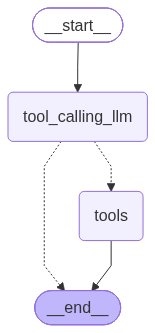

In [19]:
## Stategraph

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## node definition
def tool_calling_llm(state: State):
    return {"messages" : [llm_with_tool.invoke(state["messages"])]}

##graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))


## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",

    # if the latest message(result) from assitant is a tool call -> tools_condition routes to tool
    # if the latest message(result) from assitant is not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools", END)

##compile the grpah
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))






In [20]:
response = graph.invoke({"messages" : "What is the recent news of AI"})

In [21]:
response['messages'][-1].content

'{"query": "recent news AI 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://fastcompanyme.com/news/leap-2026-brings-billions-in-saudi-tech-investment-across-ai-infrastructure-and-gaming", "title": "LEAP 2026 puts billions behind Saudi Arabia’s next tech boom", "content": "[](\\n\\nNews\\n\\nEmirati women account for 54.7% of Dubai Government employees\\n\\n[](\\n\\nNews\\n\\nSaudi banking sector assets rise to SR5.75 trillion\\n\\n[](\\n\\nNews\\n\\nLEAP 2026 marks progress for Saudi Arabia\'s AI infrastructure\\n\\n[](\\n\\nNews\\n\\nJourneys Unpacked, the world\'s first Place Intelligence publication, announced\\n\\n[](\\n\\nLatest Stories\\n\\n#### LEAP 2026 brings billions in Saudi tech investment across AI, infrastructure and gaming\\n\\nNew commitments span data centres, AI, digital government, mobility and startups as global companies expand their presence in the kingdom Dubai-based No Competition signs five-year deal for up to 10,00

In [22]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the recent news of AI
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_eef260aa-c2c4-4dcf-85e8-bc26017540b1)
 Call ID: fc_eef260aa-c2c4-4dcf-85e8-bc26017540b1
  Args:
    query: recent news AI 2026
    search_depth: advanced
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent news AI 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://fastcompanyme.com/news/leap-2026-brings-billions-in-saudi-tech-investment-across-ai-infrastructure-and-gaming", "title": "LEAP 2026 puts billions behind Saudi Arabia’s next tech boom", "content": "[](\n\nNews\n\nEmirati women account for 54.7% of Dubai Government employees\n\n[](\n\nNews\n\nSaudi banking sector assets rise to SR5.75 trillion\n\n[](\n\nNews\n\n

## ReAct Architecture

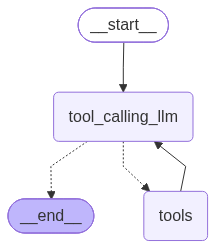

In [23]:
## Stategraph

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## node definition
def tool_calling_llm(state: State):
    return {"messages" : [llm_with_tool.invoke(state["messages"])]}

##graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))


## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",

    # if the latest message(result) from assitant is a tool call -> tools_condition routes to tool
    # if the latest message(result) from assitant is not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools", "tool_calling_llm")

##compile the grpah
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))






In [24]:
response = graph.invoke({"messages" : "Give me the recent AI News and tell me what is 2 multiply 89"})
for m in response['messages'] : 
    m.pretty_print()

================================ Human Message =================================

Give me the recent AI News and tell me what is 2 multiply 89
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_7f98a969-e742-47eb-a98f-f1946f7914ee)
 Call ID: fc_7f98a969-e742-47eb-a98f-f1946f7914ee
  Args:
    query: recent AI news 2026
    search_depth: advanced
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://blog.google/innovation-and-ai/technology/ai/google-ai-updates-july-2026", "title": "The latest AI news we announced in July 2026", "content": "Learn how AI breakthroughs can help people prepare for and respond to natural hazards. With the release of the UN report “Leveraging AI to enhance multi-hazard early warning systems,” we shared how our teams 

## Adding Memory in Agentic Graph

In [25]:
response = graph.invoke({"messages" : "My name is Kartik"})
for m in response['messages'] : 
    m.pretty_print()

================================ Human Message =================================

My name is Kartik
================================== Ai Message ==================================

Nice to meet you, Kartik! How can I help you today?


In [26]:
response = graph.invoke({"messages" : "What is my name ?"})
for m in response['messages'] : 
    m.pretty_print()

================================ Human Message =================================

What is my name ?
================================== Ai Message ==================================

I don’t have any record of your name. Could you let me know what you’d like me to call you?


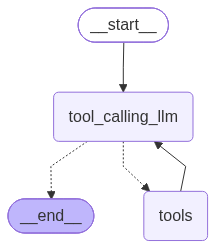

In [27]:
## Stategraph

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

## node definition
def tool_calling_llm(state: State):
    return {"messages" : [llm_with_tool.invoke(state["messages"])]}

##graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))


## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",

    # if the latest message(result) from assitant is a tool call -> tools_condition routes to tool
    # if the latest message(result) from assitant is not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools", "tool_calling_llm")

##compile the grpah
graph = builder.compile(checkpointer = memory)

display(Image(graph.get_graph().draw_mermaid_png()))






In [28]:
config = {"configurable" : {"thread_id" : "1"}} ## providing unique thread id

response = graph.invoke({"messages" : "Hi my name is Kartik"}, config = config)
response

{'messages': [HumanMessage(content='Hi my name is Kartik', additional_kwargs={}, response_metadata={}, id='68b4ecd3-381f-4de4-8b14-ca896c5ace0a'),
  AIMessage(content='Hello Kartik! How can I help you today?', additional_kwargs={'reasoning_content': 'The user says "Hi my name is Kartik". Probably respond with greeting. No request for function. Just friendly reply.'}, response_metadata={'token_usage': {'completion_tokens': 46, 'prompt_tokens': 362, 'total_tokens': 408, 'completion_time': 0.068900395, 'completion_tokens_details': {'reasoning_tokens': 26}, 'prompt_time': 0.025721183, 'prompt_tokens_details': None, 'queue_time': 0.350147691, 'total_time': 0.094621578}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_9340e7d14d', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a06694-2ac5-7193-a731-3ebd40d8a6b8-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 362, 'output_tokens': 46, 'to

In [29]:
response['messages'][-1].content

'Hello Kartik! How can I help you today?'

In [30]:
config = {"configurable" : {"thread_id" : "1"}} ## providing unique thread id

response = graph.invoke({"messages" : "Hi what is my name ?"}, config = config)
response['messages'][-1].content

'You’re Kartik.'

## Streaming

In [31]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

In [32]:
def superbot(state: State) : 
    return {"messages" : [llm.invoke(state['messages'])]}

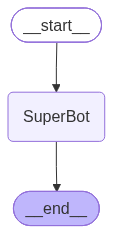

In [33]:
graph  =  StateGraph(State)

##node
graph.add_node("SuperBot", superbot)
## edges

graph.add_edge(START, "SuperBot")
graph.add_edge("SuperBot", END)

graph_builder = graph.compile(checkpointer = memory)

## display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [34]:
## invoking

config = {"configurable" : {"thread_id" : "1"}}

graph_builder.invoke({'messages' : "My name is Kartik and I like biking"}, config)

{'messages': [HumanMessage(content='My name is Kartik and I like biking', additional_kwargs={}, response_metadata={}, id='20f321c1-6ebf-4347-b66b-ece8d5d88478'),
  AIMessage(content='Nice to meet you, Kartik! 🚴\u200d♂️\n\nWhat kind of biking do you enjoy most? Trail riding, road racing, or just a leisurely spin around town? And do you have a favorite route or trail that you love to hit?', additional_kwargs={'reasoning_content': 'User says: "My name is Kartik and I like biking". They likely want a response. We should respond in friendly manner. Maybe ask about biking, location, etc. Should be concise.'}, response_metadata={'token_usage': {'completion_tokens': 102, 'prompt_tokens': 80, 'total_tokens': 182, 'completion_time': 0.114581833, 'completion_tokens_details': {'reasoning_tokens': 41}, 'prompt_time': 0.004005935, 'prompt_tokens_details': None, 'queue_time': 0.303960855, 'total_time': 0.118587768}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_d6de37e6be', 'service_t

## Streaming

##### Methods: .stream() and astream() , these methods are sync and async methods for streaming back results

###### Additional parameters in streaming modes for graph state :
###### --> values : this streams the full state of the graph after each node is called

###### --> updates : this stream updates to the state of the graph after each node is called


In [35]:
## Creating thread

config = {"configurable": {"thread_id" : "3"}}

for chunk in graph_builder.stream({'messages' : "Hi, my name is Kartik and I like you"}, config, stream_mode = "values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi, my name is Kartik and I like you', additional_kwargs={}, response_metadata={}, id='7e7c3a18-bd97-4d1f-8c62-ac27b12fb8b0')]}
{'messages': [HumanMessage(content='Hi, my name is Kartik and I like you', additional_kwargs={}, response_metadata={}, id='7e7c3a18-bd97-4d1f-8c62-ac27b12fb8b0'), AIMessage(content='Hello, Kartik! 👋 It’s great to meet you—thank you for the kind words! How can I help you today? Whether you have questions, need a recommendation, or just want to chat, I’m here for you.', additional_kwargs={'reasoning_content': 'We need to respond to a friendly user. The user says "Hi, my name is Kartik and I like you". We should respond warmly, maybe ask how can help. There\'s no policy conflict. Just friendly response.'}, response_metadata={'token_usage': {'completion_tokens': 104, 'prompt_tokens': 82, 'total_tokens': 186, 'completion_time': 0.147523684, 'completion_tokens_details': {'reasoning_tokens': 46}, 'prompt_time': 0.003979505, 'prompt

In [36]:
## Creating thread

config = {"configurable": {"thread_id" : "3"}}

for chunk in graph_builder.stream({'messages' : "Hi, my name is Kartik and I like you"}, config, stream_mode = "updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content='Hi Kartik! 👋 I’m glad to hear that—thank you! How can I help you today? Whether you’ve got a question, need a recommendation, or just want to chat, I’m all ears.', additional_kwargs={'reasoning_content': 'User says "Hi, my name is Kartik and I like you". It\'s a friendly statement. We should respond politely, acknowledging. Also we can ask how we can help. There\'s no policy conflict. No disallowed content. So we can comply.'}, response_metadata={'token_usage': {'completion_tokens': 106, 'prompt_tokens': 152, 'total_tokens': 258, 'completion_time': 0.193080005, 'completion_tokens_details': {'reasoning_tokens': 52}, 'prompt_time': 0.00930385, 'prompt_tokens_details': None, 'queue_time': 0.303369599, 'total_time': 0.202383855}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_587d0d67cc', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a06694-35b8-7613-a738-14363076

In [37]:

config = {"configurable": {"thread_id" : "4"}}

async for chunk in graph_builder.astream_events({'messages' : "Hi, my name is Kartik and I like you"}, config, stream_mode = "updates"):
    print(chunk)

{'event': 'on_chain_start', 'data': {'input': {'messages': 'Hi, my name is Kartik and I like you'}}, 'name': 'LangGraph', 'tags': [], 'run_id': '01a06694-3877-7803-96a6-1d17034e2ba0', 'metadata': {'thread_id': '4', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi, my name is Kartik and I like you', additional_kwargs={}, response_metadata={}, id='7b063227-95bd-48b1-b8a0-497d86ceb78b')]}}, 'name': 'SuperBot', 'tags': ['graph:step:1'], 'run_id': '01a06694-387b-7060-bda5-1cb37eaf833a', 'metadata': {'thread_id': '4', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'SuperBot', 'langgraph_triggers': ('branch:to:SuperBot',), 'langgraph_path': ('__pregel_pull', 'SuperBot'), 'langgraph_checkpoint_ns': 'SuperBot:96a55506-63f0-22ae-2835-5883a76933a8'}, 'parent_ids': ['01a06694-3877-7803-96a6-1d17034e2ba0']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages': [[HumanMessage(conten

### Human Feedback in the loop

In [38]:
import os 
from langchain.chat_models import init_chat_model
llm = init_chat_model("openai/gpt-oss-20b" , model_provider = "groq")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.1', 'langchain': '1.3.18'}}, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000019F6CF1C690>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000019F6CF1D090>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [43]:
from typing import Annotated

from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from typing_extensions import TypedDict

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END 
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

from langgraph.types import Command, interrupt

class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

@tool
def human_assistance(query: str) -> str:
    """Request assistance fro the human"""
    human_response = interrupt({"query" : query})
    return human_response["data"]

tool = TavilySearch(max_result =2)
tools = [tool, human_assistance]
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State): 
    message = llm_with_tools.invoke(state["messages"])
    # bcz we'll be interupting during the tool execution
    #we will disable parallel tool calling to avoid repeating any
    # tool invocations when we resume

    return {"messages" : [message]}

graph_builder.add_node("chatbot", chatbot)

tool_node = ToolNode(tools = tools)
graph_builder.add_node("tools", tool_node)

graph_builder.add_conditional_edges(
    "chatbot", 
    tools_condition,
)
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

In [44]:
memory = MemorySaver()
graph = graph_builder.compile(checkpointer =memory)

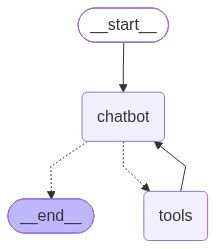

In [45]:
from IPython.display import Image, display
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception : 
    pass



In [46]:
user_input = "I need some expert guidance to build AI Agent. Could you request assistance for me ?"
config = {"configurable" : {"thread_id" : "1"}}

events = graph.stream(
    {"messages" : user_input},
    config,
    stream_mode = "values",
)

for event in events : 
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

I need some expert guidance to build AI Agent. Could you request assistance for me ?
================================== Ai Message ==================================
Tool Calls:
  human_assistance (fc_c2c403b4-9093-4681-a5d7-29a37f9659ed)
 Call ID: fc_c2c403b4-9093-4681-a5d7-29a37f9659ed
  Args:
    query: I need some expert guidance to build AI Agent. Could you request assistance for me ?
================================== Ai Message ==================================
Tool Calls:
  human_assistance (fc_c2c403b4-9093-4681-a5d7-29a37f9659ed)
 Call ID: fc_c2c403b4-9093-4681-a5d7-29a37f9659ed
  Args:
    query: I need some expert guidance to build AI Agent. Could you request assistance for me ?


In [47]:
human_response = ("We, the experts are here to help! We'd recpommend you check out Langgraph to build your agent.")

human_command = Command(resume= {"data" : human_response})

events = graph.stream(human_command, config, stream_mode = "values")
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  human_assistance (fc_c2c403b4-9093-4681-a5d7-29a37f9659ed)
 Call ID: fc_c2c403b4-9093-4681-a5d7-29a37f9659ed
  Args:
    query: I need some expert guidance to build AI Agent. Could you request assistance for me ?
================================= Tool Message =================================
Name: human_assistance

We, the experts are here to help! We'd recpommend you check out Langgraph to build your agent.
================================== Ai Message ==================================

Absolutely! We’re happy to help. A great starting point for building an AI agent is **LangGraph**. It provides a flexible framework for designing, orchestrating, and scaling conversational agents, and it integrates smoothly with popular LLMs and retrieval services. If you’d like, we can dive deeper into setting up a LangGraph project, choosing the right components, or tailoring it to your specific use case.